# Robot Navigation & Localization Analysis
## Team 02 - Assignment 02

**Comprehensive data analysis pipeline for robot navigation performance evaluation, anomaly detection, and predictive analysis.**

This notebook processes:
- `poses.csv` - Ground truth and estimated poses
- `behaviors.csv` - Behavior tree execution logs
- `rosbag2.csv` - Raw ROS topics (AMCL pose, transforms, velocity commands)
- `scenario.config` - Scenario parameters

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import yaml
import ast
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple, Any
from scipy import interpolate
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from scipy.stats import mannwhitneyu
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

DATASET_PATH = Path('ws25_aia_complete_data')
IMAGES_PATH = Path('images')
IMAGES_PATH.mkdir(exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

# Ensure saved PNGs have visible axes/ticks and a white (non-transparent) background
# (Important when the notebook uses a dark theme: otherwise axes can look "missing".)
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'savefig.edgecolor': 'white',
    'savefig.transparent': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'text.color': 'black',
    'grid.color': '#d0d0d0',
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
})

print(f'Dataset path exists: {DATASET_PATH.exists()}')

Dataset path exists: True


## 2. Data Structures

In [2]:
@dataclass
class ScenarioConfig:
    """Scenario configuration parameters."""
    goal_poses: List[Dict]
    start_pose: Dict
    laser_noise_std: float
    laser_drop_pct: float
    map_file: str

@dataclass
class AMCLData:
    """AMCL localization data from rosbag2.csv."""
    timestamps: np.ndarray  # seconds
    positions: np.ndarray   # (N, 3) x, y, z
    orientations: np.ndarray  # (N, 4) w, x, y, z quaternion
    covariances: List[np.ndarray]  # List of 6x6 covariance matrices

@dataclass
class RunMetrics:
    """Computed metrics for a single run."""
    mean_pos_error: float = 0.0
    rmse_pos: float = 0.0
    max_pos_error: float = 0.0
    mean_yaw_error: float = 0.0
    executed_path_length: float = 0.0
    gt_path_length: float = 0.0
    path_efficiency: float = 0.0
    mean_linear_velocity: float = 0.0
    max_linear_velocity: float = 0.0
    mean_angular_velocity: float = 0.0
    trajectory_smoothness: float = 0.0
    duration: float = 0.0
    # AMCL metrics from rosbag2
    mean_amcl_uncertainty: float = 0.0
    max_amcl_uncertainty: float = 0.0

@dataclass
class RunData:
    """Complete data for a single simulation run."""
    scenario_name: str
    run_id: int
    run_path: Path
    scenario_category: str = ''
    outcome: str = 'unknown'
    poses_df: Optional[pd.DataFrame] = None
    behaviors_df: Optional[pd.DataFrame] = None
    rosbag_df: Optional[pd.DataFrame] = None  # NEW: rosbag2.csv data
    amcl_data: Optional[AMCLData] = None  # NEW: Parsed AMCL data
    config: Optional[ScenarioConfig] = None
    synced_data: Optional[pd.DataFrame] = None
    metrics: Optional[RunMetrics] = None
    anomalies: List[str] = field(default_factory=list)
    time_series_metrics: Optional[pd.DataFrame] = None
    is_valid: bool = True
    error_msg: str = ''

## 3. Data Loading Module

In [3]:
class DatasetLoader:
    """Handles loading and parsing of all dataset files including rosbag2.csv."""
    
    CATEGORY_PATTERNS = {
        'door-width': r'door-width|door-size',
        'room-size': r'room-size',
        'hallway-window': r'hallway-window',
        'everything-failure': r'everything-failure',
        'floorplan-failure': r'floorplan-failure'
    }
    
    def __init__(self, dataset_path: Path):
        self.dataset_path = dataset_path
        
    def get_scenario_category(self, scenario_name: str) -> str:
        import re
        for cat, pattern in self.CATEGORY_PATTERNS.items():
            if re.search(pattern, scenario_name, re.IGNORECASE):
                return cat
        return 'other'
    
    def parse_scenario_config(self, config_path: Path) -> Optional[ScenarioConfig]:
        try:
            with open(config_path, 'r') as f:
                data = yaml.safe_load(f)
            ts = data.get('test_scenario', {})
            return ScenarioConfig(
                goal_poses=ts.get('goal_poses', []),
                start_pose=ts.get('start_pose', {}),
                laser_noise_std=float(ts.get('laserscan_gaussian_noise_std_deviation', 0.02)),
                laser_drop_pct=float(ts.get('laserscan_random_drop_percentage', 0.0)),
                map_file=ts.get('map_file', '')
            )
        except Exception:
            return None
    
    def parse_amcl_data(self, rosbag_df: pd.DataFrame) -> Optional[AMCLData]:
        """Extract AMCL pose data with uncertainty from rosbag2.csv."""
        if rosbag_df is None or rosbag_df.empty:
            return None
        amcl_rows = rosbag_df[rosbag_df['topic'] == '/amcl_pose']
        if amcl_rows.empty:
            return None
        try:
            timestamps = (amcl_rows['timestamp'].values / 1e9).astype(float)
            positions = np.column_stack([
                amcl_rows['pose.pose.position.x'].values,
                amcl_rows['pose.pose.position.y'].values,
                amcl_rows['pose.pose.position.z'].fillna(0).values
            ])
            orientations = np.column_stack([
                amcl_rows['pose.pose.orientation.w'].values,
                amcl_rows['pose.pose.orientation.x'].values,
                amcl_rows['pose.pose.orientation.y'].values,
                amcl_rows['pose.pose.orientation.z'].values
            ])
            # Parse covariance matrices
            covariances = []
            for cov_str in amcl_rows['pose.covariance'].values:
                try:
                    if isinstance(cov_str, str):
                        cov_arr = np.array(ast.literal_eval(cov_str.replace('\n', ' ')))
                    else:
                        cov_arr = np.array(cov_str)
                    covariances.append(cov_arr.reshape(6, 6))
                except:
                    covariances.append(np.eye(6) * 0.01)
            return AMCLData(timestamps=timestamps, positions=positions, 
                           orientations=orientations, covariances=covariances)
        except Exception as e:
            return None
    
    def get_run_outcome(self, behaviors_df: pd.DataFrame) -> str:
        if behaviors_df is None or behaviors_df.empty:
            return 'no_data'
        nav = behaviors_df[behaviors_df['behavior_name'].str.contains('nav_through_poses', na=False)]
        if nav.empty:
            return 'no_navigation'
        last_status = nav.iloc[-1]['status_name']
        return 'success' if last_status == 'SUCCESS' else ('failure' if last_status == 'FAILURE' else 'incomplete')
    
    def load_run(self, run_path: Path, scenario_name: str, run_id: int) -> RunData:
        run = RunData(scenario_name=scenario_name, run_id=run_id, run_path=run_path,
                      scenario_category=self.get_scenario_category(scenario_name))
        # Load poses.csv
        poses_path = run_path / 'poses.csv'
        if poses_path.exists():
            try:
                run.poses_df = pd.read_csv(poses_path)
                if run.poses_df.empty:
                    run.is_valid = False
                    run.error_msg = 'Empty poses.csv'
            except Exception as e:
                run.is_valid = False
                run.error_msg = f'Poses error: {e}'
        else:
            run.is_valid = False
            run.error_msg = 'Missing poses.csv'
        # Load behaviors.csv
        behaviors_path = run_path / 'behaviors.csv'
        if behaviors_path.exists():
            try:
                run.behaviors_df = pd.read_csv(behaviors_path)
            except Exception:
                pass
        # Load rosbag2.csv (NEW)
        rosbag_path = run_path / 'rosbag2.csv'
        if rosbag_path.exists():
            try:
                run.rosbag_df = pd.read_csv(rosbag_path, low_memory=False)
                run.amcl_data = self.parse_amcl_data(run.rosbag_df)
            except Exception:
                pass
        # Load config
        config_path = run_path / 'scenario.config'
        if config_path.exists():
            run.config = self.parse_scenario_config(config_path)
        run.outcome = self.get_run_outcome(run.behaviors_df)
        return run
    
    def load_all_runs(self, max_scenarios: int = None) -> List[RunData]:
        runs = []
        scenario_dirs = sorted([d for d in self.dataset_path.iterdir() if d.is_dir()])
        if max_scenarios:
            scenario_dirs = scenario_dirs[:max_scenarios]
        for scenario_dir in tqdm(scenario_dirs, desc='Loading scenarios'):
            scenario_name = scenario_dir.name
            run_dirs = sorted([d for d in scenario_dir.iterdir() if d.is_dir() and d.name.isdigit()])
            for run_dir in run_dirs:
                run = self.load_run(run_dir, scenario_name, int(run_dir.name))
                runs.append(run)
        return runs

loader = DatasetLoader(DATASET_PATH)
print('Loader initialized with rosbag2 support')

Loader initialized with rosbag2 support


## 4. Data Preprocessing Pipeline

In [4]:
class DataPreprocessor:
    """Handles data synchronization and preprocessing."""
    
    @staticmethod
    def normalize_yaw(yaw: np.ndarray) -> np.ndarray:
        return np.arctan2(np.sin(yaw), np.cos(yaw))
    
    @staticmethod
    def quaternion_to_yaw(w, x, y, z):
        """Convert quaternion to yaw angle."""
        siny_cosp = 2 * (w * z + x * y)
        cosy_cosp = 1 - 2 * (y * y + z * z)
        return np.arctan2(siny_cosp, cosy_cosp)
    
    @staticmethod
    def sync_poses(poses_df: pd.DataFrame) -> Optional[pd.DataFrame]:
        if poses_df is None or poses_df.empty:
            return None
        gt_df = poses_df[poses_df['frame'] == 'nav2_turtlebot4_base_link_gt'].copy()
        est_df = poses_df[poses_df['frame'] == 'base_link'].copy()
        if gt_df.empty or est_df.empty:
            return None
        gt_df = gt_df.sort_values('timestamp').drop_duplicates('timestamp')
        est_df = est_df.sort_values('timestamp').drop_duplicates('timestamp')
        est_times = est_df['timestamp'].values
        gt_times = gt_df['timestamp'].values
        if len(gt_times) < 2:
            return None
        valid_mask = (est_times >= gt_times.min()) & (est_times <= gt_times.max())
        est_df = est_df[valid_mask]
        if len(est_df) < 2:
            return None
        synced = est_df.copy()
        synced = synced.rename(columns={'position.x': 'est_x', 'position.y': 'est_y', 'orientation.yaw': 'est_yaw'})
        for col, new_col in [('position.x', 'gt_x'), ('position.y', 'gt_y'), ('orientation.yaw', 'gt_yaw')]:
            f = interpolate.interp1d(gt_times, gt_df[col].values, kind='linear', fill_value='extrapolate')
            synced[new_col] = f(synced['timestamp'].values)
        synced['gt_yaw'] = DataPreprocessor.normalize_yaw(synced['gt_yaw'].values)
        synced['est_yaw'] = DataPreprocessor.normalize_yaw(synced['est_yaw'].values)
        synced = synced[['timestamp', 'est_x', 'est_y', 'est_yaw', 'gt_x', 'gt_y', 'gt_yaw']]
        return synced.reset_index(drop=True)
    
    @staticmethod
    def filter_stationary(synced_df: pd.DataFrame, velocity_threshold: float = 0.01) -> pd.DataFrame:
        if synced_df is None or len(synced_df) < 3:
            return synced_df
        dx = np.diff(synced_df['est_x'].values)
        dy = np.diff(synced_df['est_y'].values)
        dt = np.diff(synced_df['timestamp'].values)
        dt = np.where(dt == 0, 1e-6, dt)
        velocity = np.sqrt(dx**2 + dy**2) / dt
        velocity = np.concatenate([[velocity[0]], velocity])
        moving_mask = velocity > velocity_threshold
        first_moving = np.argmax(moving_mask)
        last_moving = len(moving_mask) - np.argmax(moving_mask[::-1]) - 1
        return synced_df.iloc[first_moving:last_moving+1].reset_index(drop=True)
    
    def preprocess(self, run: RunData, filter_stationary: bool = True) -> RunData:
        if not run.is_valid:
            return run
        synced = self.sync_poses(run.poses_df)
        if synced is None or len(synced) < 10:
            run.is_valid = False
            run.error_msg = 'Sync failed'
            return run
        if filter_stationary:
            synced = self.filter_stationary(synced)
        if synced is None or len(synced) < 5:
            run.is_valid = False
            run.error_msg = 'Too few points after filtering'
            return run
        run.synced_data = synced
        return run

preprocessor = DataPreprocessor()
print('Preprocessor initialized')

Preprocessor initialized


## 5. Metric Calculation Engine

### A) Per-run (aggregated) metrics — `RunMetrics`

#### A1. Localization accuracy (position)
1. **mean_pos_error** *(meters, m)*  
   - **Definition:** Average Euclidean distance between estimated and ground-truth positions.  
   - **Computed as:** mean of `sqrt((est_x-gt_x)^2 + (est_y-gt_y)^2)` over all synced timestamps.  
   - **Interpretation:** Lower is better.

2. **rmse_pos** *(m)*  
   - **Definition:** Root mean square of position error (penalizes large errors more than mean).  
   - **Computed as:** `sqrt(mean(pos_error^2))`.  
   - **Interpretation:** Lower is better; sensitive to spikes.

3. **max_pos_error** *(m)*  
   - **Definition:** Maximum instantaneous position error over the run.  
   - **Computed as:** `max(pos_error)`.  
   - **Interpretation:** Highlights worst-case deviations.

#### A2. Localization accuracy (orientation)
4. **mean_yaw_error** *(radians, rad)*  
   - **Definition:** Average absolute yaw difference between estimate and ground truth.  
   - **Computed as:** mean of `abs(wrap_to_pi(est_yaw - gt_yaw))`.  
   - **Interpretation:** Lower is better.

#### A3. Path geometry & efficiency
5. **executed_path_length** *(m)*  
   - **Definition:** Total traveled distance along the **estimated** trajectory.  
   - **Computed as:** sum of segment lengths `sum(sqrt(dx^2+dy^2))` over `(est_x, est_y)`.  
   - **Interpretation:** Larger can indicate detours/oscillation.

6. **gt_path_length** *(m)*  
   - **Definition:** Total distance along the **ground-truth** trajectory.  
   - **Computed as:** same path-length computation but on `(gt_x, gt_y)`.  
   - **Interpretation:** Baseline difficulty/true motion length.

7. **path_efficiency** *(unitless ratio)*  
   - **Definition:** How direct the executed motion is relative to ground truth.  
   - **Computed as:** `gt_path_length / executed_path_length` (0 if executed length is 0).  
   - **Interpretation:** Closer to 1 is better; low values suggest detours.

#### A4. Kinematics & smoothness
8. **mean_linear_velocity** *(m/s)*  
   - **Definition:** Mean translational speed derived from estimated motion.  
   - **Computed as:** mean of `sqrt(dx^2+dy^2)/dt`.  
   - **Interpretation:** Context for speed-vs-accuracy tradeoffs.

9. **max_linear_velocity** *(m/s)*  
   - **Definition:** Peak translational speed.  
   - **Computed as:** max of `sqrt(dx^2+dy^2)/dt`.

10. **mean_angular_velocity** *(rad/s)*  
   - **Definition:** Mean turning rate magnitude.  
   - **Computed as:** mean of `abs(wrap_to_pi(dyaw))/dt`.

11. **trajectory_smoothness** *(rad/s²)*  
   - **Definition:** Average absolute angular acceleration magnitude.  
   - **Computed as:** mean of `abs(diff(angular_vel)/dt)` (with safe handling for zero dt).  
   - **Interpretation:** Lower is smoother; higher implies oscillation/jerky turning.

12. **duration** *(seconds, s)*  
   - **Definition:** Total time span of the synced segment.  
   - **Computed as:** `timestamp_last - timestamp_first`.

#### A5. AMCL uncertainty (from `rosbag2.csv` → `/amcl_pose`)
13. **mean_amcl_uncertainty** *(meters-equivalent, m)*  
   - **Definition:** Average positional uncertainty proxy from AMCL covariance.  
   - **Computed as:** for each covariance `cov`, use `sqrt(cov[0,0] + cov[1,1])`, then take the mean.  
   - **Interpretation:** Higher values indicate less confident localization.

14. **max_amcl_uncertainty** *(m)*  
   - **Definition:** Maximum observed AMCL positional uncertainty proxy.  
   - **Computed as:** max over `sqrt(cov[0,0] + cov[1,1])`.

---

### B) Per-timestamp time-series metrics — `run.time_series_metrics`

These are computed for each synced timestamp (and are used for plots + rule-based anomaly checks):

1. **pos_error** *(m)*  
   - `sqrt((est_x-gt_x)^2 + (est_y-gt_y)^2)`

2. **yaw_error** *(rad)*  
   - `abs(wrap_to_pi(est_yaw - gt_yaw))`

3. **linear_vel** *(m/s)*  
   - Derived from consecutive estimated positions: `sqrt(dx^2+dy^2)/dt`

4. **angular_vel** *(rad/s)*  
   - Derived from consecutive estimated yaw values: `abs(wrap_to_pi(dyaw))/dt`

---


### C) Summary/analysis-level fields in `summary_df`

These are not “new sensors”, but derived from run-level results:
- **anomaly_count** *(count)* — number of anomalies assigned to a run.  
- **anomalies** *(string list)* — comma-separated anomaly labels for reporting/plots.

In [5]:
class MetricCalculator:
    """Computes performance metrics including AMCL uncertainty."""
    
    @staticmethod
    def compute_position_error(synced: pd.DataFrame) -> np.ndarray:
        return np.sqrt((synced['est_x'] - synced['gt_x'])**2 + (synced['est_y'] - synced['gt_y'])**2)
    
    @staticmethod
    def compute_yaw_error(synced: pd.DataFrame) -> np.ndarray:
        diff = synced['est_yaw'] - synced['gt_yaw']
        return np.abs(np.arctan2(np.sin(diff), np.cos(diff)))
    
    @staticmethod
    def compute_path_length(x: np.ndarray, y: np.ndarray) -> float:
        return float(np.sum(np.sqrt(np.diff(x)**2 + np.diff(y)**2)))
    
    @staticmethod
    def compute_velocities(synced: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray]:
        t = synced['timestamp'].values
        dt = np.diff(t)
        dt = np.where(dt == 0, 1e-6, dt)
        dx = np.diff(synced['est_x'].values)
        dy = np.diff(synced['est_y'].values)
        dyaw = np.diff(synced['est_yaw'].values)
        dyaw = np.arctan2(np.sin(dyaw), np.cos(dyaw))
        linear_vel = np.sqrt(dx**2 + dy**2) / dt
        angular_vel = np.abs(dyaw) / dt
        return linear_vel, angular_vel
    
    @staticmethod
    def compute_trajectory_smoothness(angular_vel: np.ndarray, dt: np.ndarray) -> float:
        if len(angular_vel) < 2:
            return 0.0
        dt_safe = np.where(dt[:-1] == 0, 1e-6, dt[:-1]) if len(dt) > len(angular_vel)-1 else dt
        angular_acc = np.diff(angular_vel) / dt_safe[:len(angular_vel)-1]
        return float(np.mean(np.abs(angular_acc)))
    
    @staticmethod
    def compute_amcl_uncertainty(amcl_data: Optional[AMCLData]) -> Tuple[float, float]:
        """Compute mean and max positional uncertainty from AMCL covariance."""
        if amcl_data is None or not amcl_data.covariances:
            return 0.0, 0.0
        # Extract position uncertainty (trace of xy covariance)
        uncertainties = []
        for cov in amcl_data.covariances:
            pos_uncertainty = np.sqrt(cov[0, 0] + cov[1, 1])  # sqrt of trace xy
            uncertainties.append(pos_uncertainty)
        return float(np.mean(uncertainties)), float(np.max(uncertainties))
    
    def compute_time_series(self, synced: pd.DataFrame) -> pd.DataFrame:
        pos_error = self.compute_position_error(synced)
        yaw_error = self.compute_yaw_error(synced)
        linear_vel, angular_vel = self.compute_velocities(synced)
        ts = pd.DataFrame({
            'timestamp': synced['timestamp'].values,
            'pos_error': pos_error,
            'yaw_error': yaw_error
        })
        ts['linear_vel'] = np.concatenate([[linear_vel[0]], linear_vel])
        ts['angular_vel'] = np.concatenate([[angular_vel[0]], angular_vel])
        return ts
    
    def compute_metrics(self, run: RunData) -> RunData:
        if not run.is_valid or run.synced_data is None:
            return run
        synced = run.synced_data
        pos_error = self.compute_position_error(synced)
        yaw_error = self.compute_yaw_error(synced)
        linear_vel, angular_vel = self.compute_velocities(synced)
        executed_path = self.compute_path_length(synced['est_x'].values, synced['est_y'].values)
        gt_path = self.compute_path_length(synced['gt_x'].values, synced['gt_y'].values)
        dt = np.diff(synced['timestamp'].values)
        mean_amcl, max_amcl = self.compute_amcl_uncertainty(run.amcl_data)
        run.metrics = RunMetrics(
            mean_pos_error=float(np.mean(pos_error)),
            rmse_pos=float(np.sqrt(np.mean(pos_error**2))),
            max_pos_error=float(np.max(pos_error)),
            mean_yaw_error=float(np.mean(yaw_error)),
            executed_path_length=executed_path,
            gt_path_length=gt_path,
            path_efficiency=gt_path / executed_path if executed_path > 0 else 0,
            mean_linear_velocity=float(np.mean(linear_vel)),
            max_linear_velocity=float(np.max(linear_vel)),
            mean_angular_velocity=float(np.mean(angular_vel)),
            trajectory_smoothness=self.compute_trajectory_smoothness(angular_vel, dt),
            duration=float(synced['timestamp'].iloc[-1] - synced['timestamp'].iloc[0]),
            mean_amcl_uncertainty=mean_amcl,
            max_amcl_uncertainty=max_amcl
        )
        run.time_series_metrics = self.compute_time_series(synced)
        return run

metric_calculator = MetricCalculator()
print('Metric calculator initialized with AMCL uncertainty')

Metric calculator initialized with AMCL uncertainty


## 6. Anomaly Detection System


### 1) Rule-based anomalies — `RuleBasedAnomalyDetector`

1. **goal_failure**  
   - **Triggered when:** behavior outcome indicates navigation ended in failure (`outcome == 'failure'`).  
   - **Purpose:** Separates explicit task failure from degraded-but-successful runs.

2. **no_initiation**  
   - **Triggered when:** no behavior data or no navigation behavior present (`outcome in {'no_data','no_navigation'}`).  
   - **Purpose:** Captures missing logs / navigation never started.

3. **position_error_spike**  
   - **Triggered when:** position error exceeds a global threshold for *K* consecutive frames.  
   - **Threshold:** `global_mean + pos_error_sigma * global_std` computed across all valid runs’ `pos_error`.  
   - **Consecutive requirement:** `consecutive_frames` (default 3).  
   - **Purpose:** Detects sustained localization divergence, not single-point noise.

4. **stuck**  
   - **Triggered when:** `linear_vel < velocity_threshold` continuously for longer than `duration_threshold`.  
   - **Defaults:** `velocity_threshold=0.01 m/s`, `duration_threshold=5.0 s`.  
   - **Purpose:** Detects immobilization / inability to progress.

5. **high_amcl_uncertainty**  
   - **Triggered when:** `mean_amcl_uncertainty > threshold`.  
   - **Default:** `threshold=0.5` (using the notebook’s uncertainty proxy).  
   - **Purpose:** Flags runs where AMCL reports persistently poor confidence.

6. **high_yaw_error**  
   - **Triggered when:** `mean_yaw_error > 0.5 rad`.  
   - **Purpose:** Detects runs with poor orientation tracking.

7. **path_inefficiency**  
   - **Triggered when:** `path_efficiency < 0.6`.  
   - **Purpose:** Flags excessive detours or "wandering" behavior.

8. **oscillation**  
   - **Triggered when:** `trajectory_smoothness > 2.0`.  
   - **Purpose:** Detects jerky motion or control instability.

---

### 2) ML-based anomaly — `MLAnomalyDetector` (Isolation Forest)

9. **ml_anomaly**  
   - **Triggered when:** Isolation Forest predicts the run as an outlier (`-1`) in standardized feature space.  
   - **Features used (exact list, in order):**  
     1) mean_pos_error  
     2) rmse_pos  
     3) max_pos_error  
     4) mean_yaw_error  
     5) executed_path_length  
     6) duration  
     7) path_efficiency  
     8) mean_linear_velocity  
     9) trajectory_smoothness  
     10) mean_amcl_uncertainty  
     11) max_amcl_uncertainty  
   - **Note:** Model is only fitted if enough valid runs exist (guarded in code).  
   - **Purpose:** Captures multi-metric abnormal patterns that rules may miss.

In [6]:
class RuleBasedAnomalyDetector:
    """Rule-based anomaly detection using multiple data sources."""
    
    def __init__(self, pos_error_sigma: float = 3.0, consecutive_frames: int = 3):
        self.pos_error_sigma = pos_error_sigma
        self.consecutive_frames = consecutive_frames
        self.global_pos_error_stats = None
    
    def compute_global_stats(self, runs: List[RunData]):
        all_errors = []
        for run in runs:
            if run.is_valid and run.time_series_metrics is not None:
                all_errors.extend(run.time_series_metrics['pos_error'].values)
        if all_errors:
            self.global_pos_error_stats = {'mean': np.mean(all_errors), 'std': np.std(all_errors)}
    
    def detect_goal_failure(self, run: RunData) -> bool:
        return run.outcome == 'failure'
    
    def detect_no_initiation(self, run: RunData) -> bool:
        return run.outcome == 'no_data' or run.outcome == 'no_navigation'
    
    def detect_position_error_spike(self, run: RunData) -> bool:
        if not run.is_valid or run.time_series_metrics is None or self.global_pos_error_stats is None:
            return False
        threshold = self.global_pos_error_stats['mean'] + self.pos_error_sigma * self.global_pos_error_stats['std']
        errors = run.time_series_metrics['pos_error'].values
        above_threshold = errors > threshold
        for i in range(len(above_threshold) - self.consecutive_frames + 1):
            if all(above_threshold[i:i+self.consecutive_frames]):
                return True
        return False
    
    def detect_stuck(self, run: RunData, velocity_threshold: float = 0.01, duration_threshold: float = 5.0) -> bool:
        if not run.is_valid or run.time_series_metrics is None:
            return False
        ts = run.time_series_metrics
        stuck_mask = ts['linear_vel'] < velocity_threshold
        start = None
        for i, is_stuck in enumerate(stuck_mask):
            if is_stuck and start is None:
                start = ts['timestamp'].iloc[i]
            elif not is_stuck and start is not None:
                duration = ts['timestamp'].iloc[i] - start
                if duration > duration_threshold:
                    return True
                start = None
        return False
    
    def detect_high_amcl_uncertainty(self, run: RunData, threshold: float = 0.5) -> bool:
        """Detect high localization uncertainty from AMCL."""
        if run.metrics is None:
            return False
        return run.metrics.mean_amcl_uncertainty > threshold
    
    def detect_high_yaw_error(self, run: RunData, threshold: float = 0.5) -> bool:
        return run.metrics.mean_yaw_error > threshold if run.metrics else False

    def detect_path_inefficiency(self, run: RunData, threshold: float = 0.6) -> bool:
        return run.metrics.path_efficiency < threshold if run.metrics else False

    def detect_oscillation(self, run: RunData, threshold: float = 2.0) -> bool:
        return run.metrics.trajectory_smoothness > threshold if run.metrics else False
    
    def detect_all(self, run: RunData) -> List[str]:
        anomalies = []
        if self.detect_goal_failure(run):
            anomalies.append('goal_failure')
        if self.detect_no_initiation(run):
            anomalies.append('no_initiation')
        if self.detect_position_error_spike(run):
            anomalies.append('position_error_spike')
        if self.detect_stuck(run):
            anomalies.append('stuck')
        if self.detect_high_amcl_uncertainty(run):
            anomalies.append('high_amcl_uncertainty')
        if self.detect_high_yaw_error(run):
            anomalies.append('high_yaw_error')
        if self.detect_path_inefficiency(run):
            anomalies.append('path_inefficiency')
        if self.detect_oscillation(run):
            anomalies.append('oscillation')
        return anomalies

class MLAnomalyDetector:
    """ML-based anomaly detection using Isolation Forest."""
    
    def __init__(self, contamination: float = 0.1):
        self.contamination = contamination
        self.model = IsolationForest(contamination=contamination, random_state=42, n_estimators=100)
        self.scaler = StandardScaler()
        self.is_fitted = False
    
    def extract_features(self, run: RunData) -> Optional[np.ndarray]:
        if not run.is_valid or run.metrics is None:
            return None
        m = run.metrics
        return np.array([
            m.mean_pos_error, m.rmse_pos, m.max_pos_error, m.mean_yaw_error,
            m.executed_path_length, m.duration, m.path_efficiency,
            m.mean_linear_velocity, m.trajectory_smoothness,
            m.mean_amcl_uncertainty, m.max_amcl_uncertainty  # NEW: AMCL features
        ])
    
    def fit(self, runs: List[RunData]):
        features = [self.extract_features(r) for r in runs if r.is_valid and r.metrics is not None]
        features = [f for f in features if f is not None]
        if len(features) < 10:
            return
        X = np.vstack(features)
        X_scaled = self.scaler.fit_transform(X)
        self.model.fit(X_scaled)
        self.is_fitted = True
    
    def predict(self, run: RunData) -> bool:
        if not self.is_fitted:
            return False
        features = self.extract_features(run)
        if features is None:
            return False
        X_scaled = self.scaler.transform(features.reshape(1, -1))
        return self.model.predict(X_scaled)[0] == -1

rule_detector = RuleBasedAnomalyDetector()
ml_detector = MLAnomalyDetector(contamination=0.15)
print('Anomaly detectors initialized with AMCL-based detection')

Anomaly detectors initialized with AMCL-based detection


## 7. Load and Process Data

In [7]:
# Load all runs
print('Loading dataset (this may take a few minutes)...')
all_runs = loader.load_all_runs(max_scenarios=100)  # Set to e.g. 50 for faster processing
print(f'Loaded {len(all_runs)} total runs')

# Count runs with rosbag data
runs_with_rosbag = sum(1 for r in all_runs if r.rosbag_df is not None)
runs_with_amcl = sum(1 for r in all_runs if r.amcl_data is not None)
print(f'Runs with rosbag2.csv: {runs_with_rosbag}')
print(f'Runs with parsed AMCL data: {runs_with_amcl}')

# Preprocess
print('\nPreprocessing...')
for run in tqdm(all_runs, desc='Preprocessing'):
    preprocessor.preprocess(run)

valid_runs = [r for r in all_runs if r.is_valid]
print(f'Valid runs after preprocessing: {len(valid_runs)}')

# Compute metrics
print('\nComputing metrics...')
for run in tqdm(valid_runs, desc='Computing metrics'):
    metric_calculator.compute_metrics(run)

# Anomaly detection
print('\nDetecting anomalies...')
rule_detector.compute_global_stats(valid_runs)
ml_detector.fit(valid_runs)

for run in valid_runs:
    run.anomalies = rule_detector.detect_all(run)
    if ml_detector.predict(run):
        run.anomalies.append('ml_anomaly')

print('\n✅ Processing complete!')

Loading dataset (this may take a few minutes)...


Loading scenarios:   0%|          | 0/100 [00:00<?, ?it/s]

Loaded 300 total runs
Runs with rosbag2.csv: 300
Runs with parsed AMCL data: 300

Preprocessing...


Preprocessing:   0%|          | 0/300 [00:00<?, ?it/s]

Valid runs after preprocessing: 300

Computing metrics...


Computing metrics:   0%|          | 0/300 [00:00<?, ?it/s]


Detecting anomalies...

✅ Processing complete!


## 8. Results Summary

In [8]:
# Create summary DataFrame with AMCL metrics
summary_data = []
for run in valid_runs:
    if run.metrics:
        m = run.metrics
        summary_data.append({
            'scenario': run.scenario_name,
            'run_id': run.run_id,
            'category': run.scenario_category,
            'outcome': run.outcome,
            'mean_pos_error': m.mean_pos_error,
            'rmse_pos': m.rmse_pos,
            'max_pos_error': m.max_pos_error,
            'mean_yaw_error': m.mean_yaw_error,
            'path_length': m.executed_path_length,
            'duration': m.duration,
            'path_efficiency': m.path_efficiency,
            'mean_velocity': m.mean_linear_velocity,
            'smoothness': m.trajectory_smoothness,
            'amcl_uncertainty': m.mean_amcl_uncertainty,
            'max_amcl_uncertainty': m.max_amcl_uncertainty,
            'anomaly_count': len(run.anomalies),
            'anomalies': ','.join(run.anomalies) if run.anomalies else 'none'
        })

summary_df = pd.DataFrame(summary_data)
print(f'Summary DataFrame: {len(summary_df)} runs')
print('\nOutcome distribution:')
print(summary_df['outcome'].value_counts())
print('\nCategory distribution:')
print(summary_df['category'].value_counts())
print('\nFirst 10 runs:')
summary_df.head(10)

Summary DataFrame: 300 runs

Outcome distribution:
outcome
failure       150
success       141
incomplete      9
Name: count, dtype: int64

Category distribution:
category
door-width        120
hallway-window    120
room-size          60
Name: count, dtype: int64

First 10 runs:


,scenario,run_id,category,outcome,mean_pos_error,rmse_pos,max_pos_error,mean_yaw_error,path_length,duration,path_efficiency,mean_velocity,smoothness,amcl_uncertainty,max_amcl_uncertainty,anomaly_count,anomalies
0,small-dataset-maps-0-3-door-width-1f1-1,0,door-width,failure,0.030531,0.032783,0.050145,0.035955,0.436571,12.780,0.734568,0.034172,0.485437,0.141421,0.141421,1,goal_failure
1,small-dataset-maps-0-3-door-width-1f1-1,1,door-width,failure,0.028770,0.029987,0.037632,0.035155,0.416911,12.204,0.782961,0.034182,0.523786,0.141421,0.141421,1,goal_failure
2,small-dataset-maps-0-3-door-width-1f1-1,2,door-width,failure,0.014917,0.017303,0.057332,0.037295,0.426768,12.204,0.752275,0.035015,0.460603,0.141421,0.141421,1,goal_failure
3,small-dataset-maps-0-33-door-width-1f1-2,0,door-width,failure,0.039765,0.042165,0.075979,0.051867,0.445250,12.384,0.718107,0.035986,0.417989,0.141421,0.141421,1,goal_failure
4,small-dataset-maps-0-33-door-width-1f1-2,1,door-width,failure,0.024151,0.025029,0.030575,0.043916,0.422645,12.204,0.759025,0.034632,0.627144,0.141421,0.141421,1,goal_failure
5,small-dataset-maps-0-33-door-width-1f1-2,2,door-width,failure,0.040881,0.042126,0.050896,0.040897,0.441391,11.484,0.736545,0.038504,0.621034,0.141421,0.141421,1,goal_failure
6,small-dataset-maps-0-36-door-width-1f1-3,0,door-width,failure,0.029375,0.030969,0.049416,0.040551,5.776273,30.492,0.967517,0.189586,0.492561,0.141421,0.141421,2,"goal_failure,stuck"
7,small-dataset-maps-0-36-door-width-1f1-3,1,door-width,failure,0.067182,0.072472,0.117401,0.031046,5.882901,28.404,0.962131,0.207257,0.570935,0.141421,0.141421,1,goal_failure
8,small-dataset-maps-0-36-door-width-1f1-3,2,door-width,failure,0.036788,0.040208,0.073733,0.037461,5.975937,31.824,0.965607,0.187997,0.502171,0.141421,0.141421,2,"goal_failure,stuck"
9,small-dataset-maps-0-44-door-width-1f1-4,0,door-width,failure,0.043892,0.049549,0.070033,0.030980,3.057508,29.631,0.904873,0.103282,0.602232,0.141421,0.141421,1,goal_failure


## 9. Visualizations

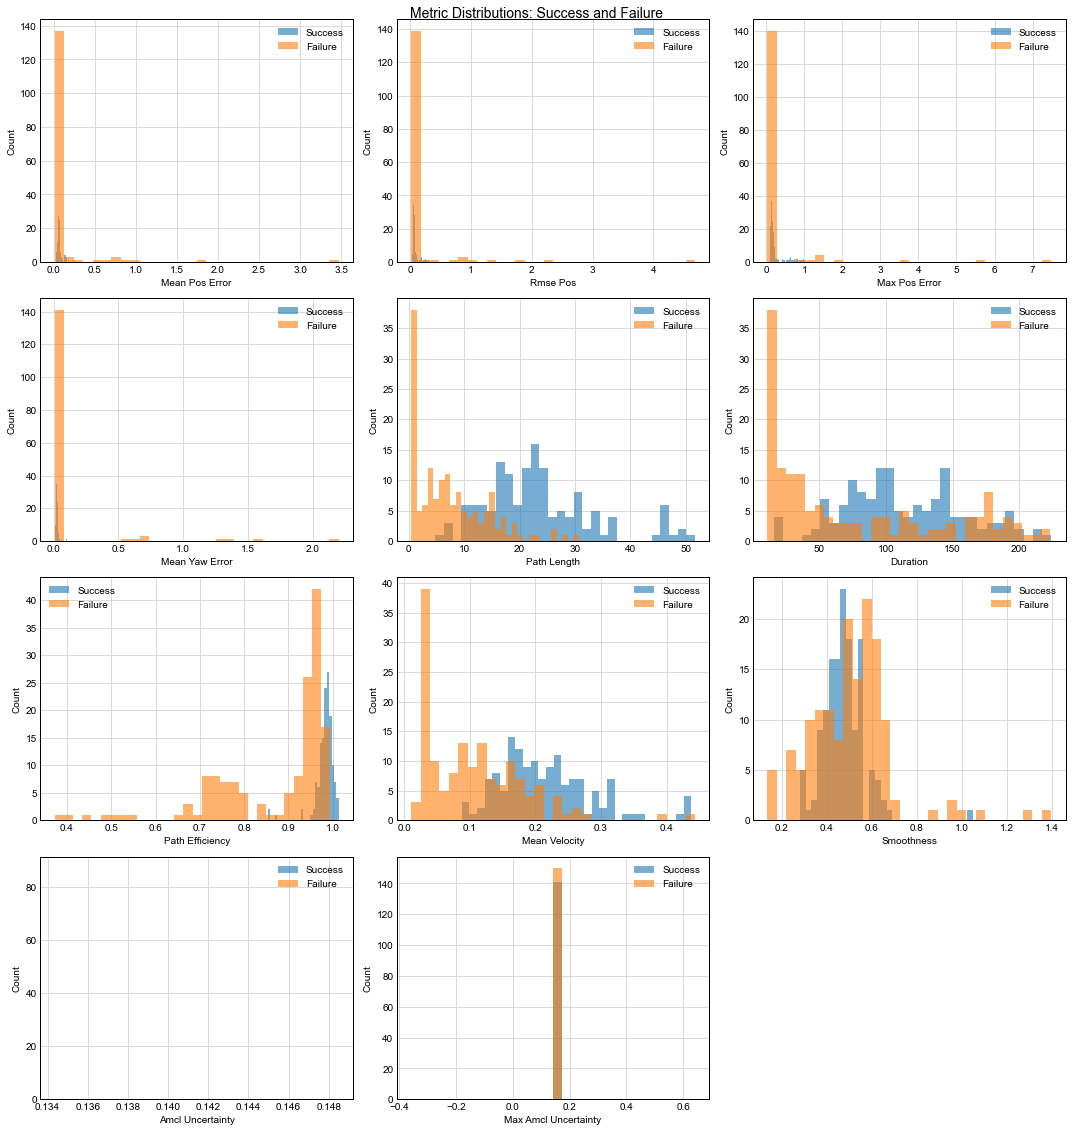

In [9]:
# 9.1 Metric distributions by outcome
metrics_to_plot = ['mean_pos_error', 'rmse_pos', 'max_pos_error', 'mean_yaw_error','path_length','duration','path_efficiency','mean_velocity','smoothness','amcl_uncertainty','max_amcl_uncertainty',]
rows = (len(metrics_to_plot) + 2) // 3
fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))

for ax, metric in zip(axes.flat, metrics_to_plot):
    for outcome in ['success', 'failure']:
        data = summary_df[summary_df['outcome'] == outcome][metric].dropna()
        if len(data) > 0:
            ax.hist(data, bins=30, alpha=0.6, label=outcome.capitalize())
    ax.set_xlabel(metric.replace('_', ' ').title())
    ax.set_ylabel('Count')
    ax.legend()

# Hide unused subplots
for i in range(len(metrics_to_plot), rows * 3):
    axes.flat[i].set_visible(False)

plt.suptitle('Metric Distributions: Success and Failure', fontsize=14)
plt.tight_layout()
plt.savefig(IMAGES_PATH / 'metric_distributions.png', dpi=150)
plt.show()

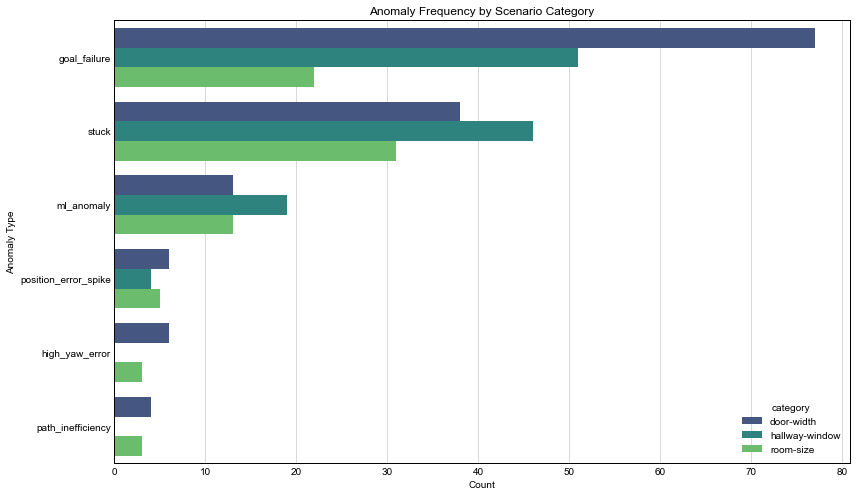

In [10]:
# 9.2 Anomaly distribution by category
anomaly_data = []
for run in valid_runs:
    for a in run.anomalies:
        anomaly_data.append({'category': run.scenario_category, 'anomaly': a})

if anomaly_data:
    df_anom = pd.DataFrame(anomaly_data)
    fig, ax = plt.subplots(figsize=(12, 7))
    sns.countplot(data=df_anom, y='anomaly', hue='category', ax=ax, palette='viridis')
    ax.set_title('Anomaly Frequency by Scenario Category')
    ax.set_xlabel('Count')
    ax.set_ylabel('Anomaly Type')
    plt.tight_layout()
    plt.savefig(IMAGES_PATH / 'anomaly_by_category.png', dpi=150)
    plt.show()

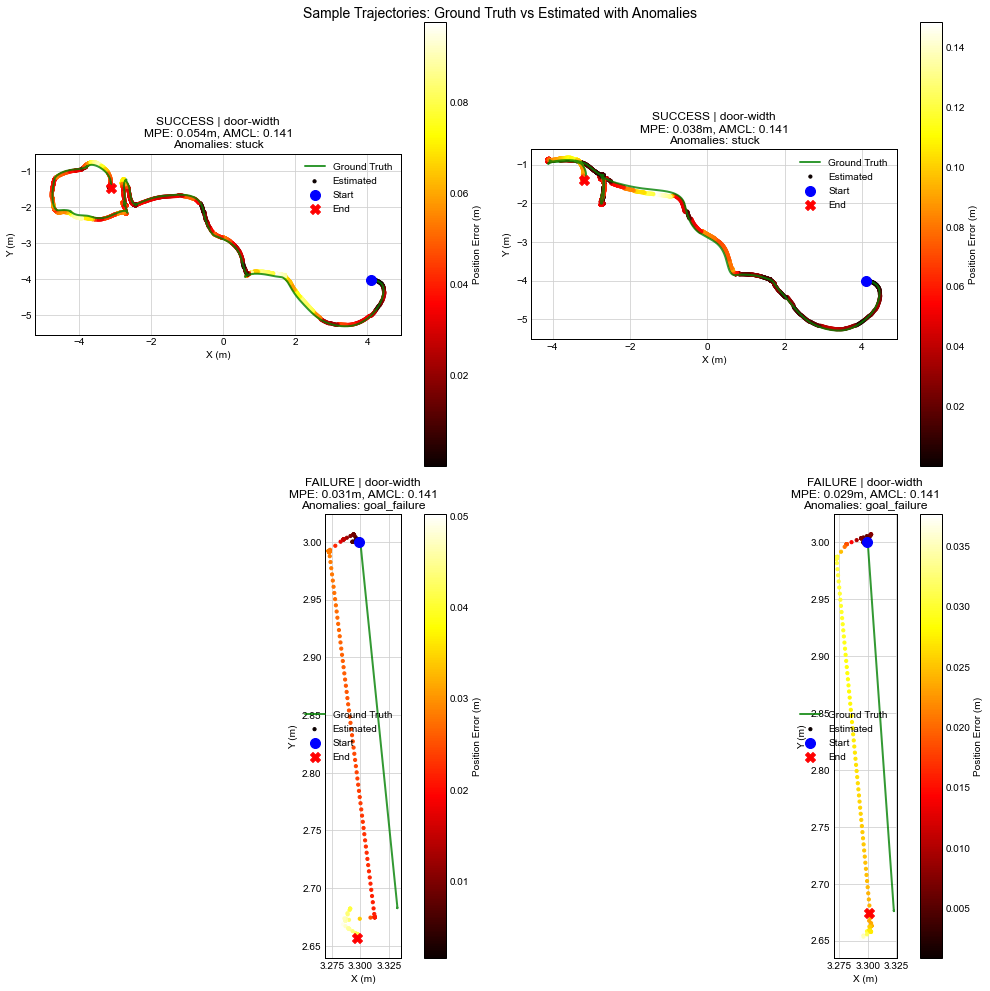

In [11]:
# 9.3 Sample trajectory visualization
sample_runs = [r for r in valid_runs if r.outcome == 'success'][:2] + [r for r in valid_runs if r.outcome == 'failure'][:2]

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
for ax, run in zip(axes.flat, sample_runs):
    if run.synced_data is not None:
        synced = run.synced_data
        ax.plot(synced['gt_x'], synced['gt_y'], 'g-', linewidth=2, label='Ground Truth', alpha=0.8)
        errors = MetricCalculator.compute_position_error(synced)
        scatter = ax.scatter(synced['est_x'], synced['est_y'], c=errors, cmap='hot', s=10, label='Estimated')
        ax.scatter(synced['est_x'].iloc[0], synced['est_y'].iloc[0], c='blue', s=100, marker='o', label='Start', zorder=5)
        ax.scatter(synced['est_x'].iloc[-1], synced['est_y'].iloc[-1], c='red', s=100, marker='X', label='End', zorder=5)
        plt.colorbar(scatter, ax=ax, label='Position Error (m)')
        ax.set_xlabel('X (m)')
        ax.set_ylabel('Y (m)')
        amcl_str = f', AMCL: {run.metrics.mean_amcl_uncertainty:.3f}' if run.metrics else ''
        anom_str = f'\nAnomalies: {", ".join(run.anomalies)}' if run.anomalies else '\nNo Anomalies'
        ax.set_title(f'{run.outcome.upper()} | {run.scenario_category}\nMPE: {run.metrics.mean_pos_error:.3f}m{amcl_str}{anom_str}')
        ax.legend(loc='best')
        ax.set_aspect('equal')
plt.suptitle('Sample Trajectories: Ground Truth vs Estimated with Anomalies', fontsize=14)
plt.tight_layout()
plt.savefig(IMAGES_PATH / 'sample_trajectories.png', dpi=150)
plt.show()

Categories plotted: ['door-width', 'hallway-window', 'room-size']
Anomaly labels used: ['goal_failure', 'high_yaw_error', 'ml_anomaly', 'path_inefficiency', 'position_error_spike', 'stuck']


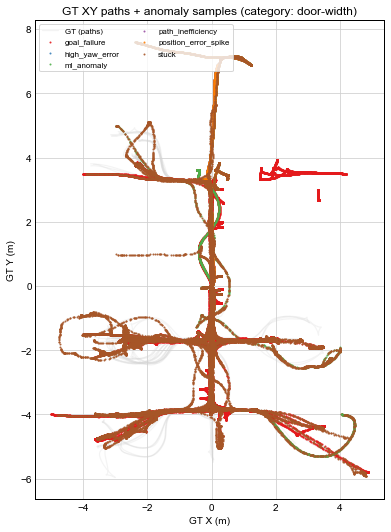

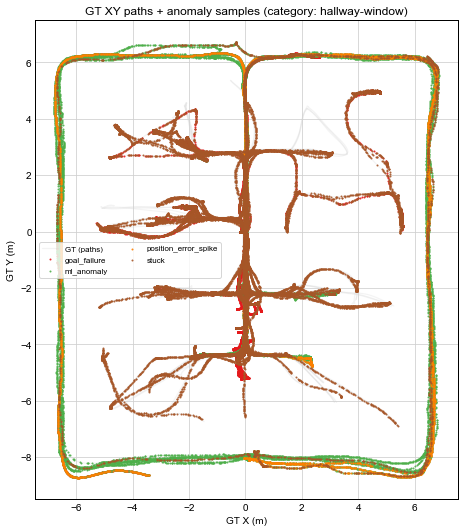

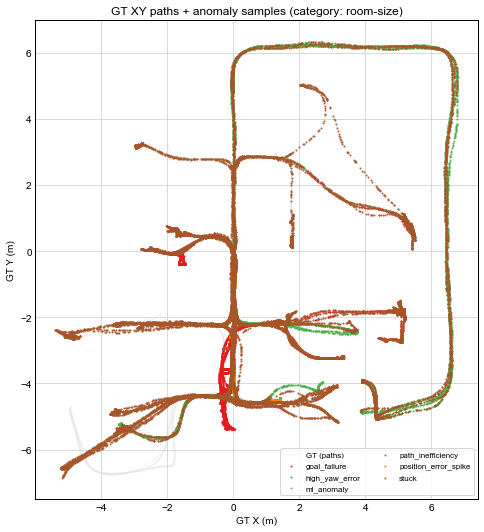

In [12]:
# 9.4 XY anomaly hotspots (GT position) by category
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

IGNORED_ANOMS = {}

def _safe_slug(s: str) -> str:
    s = str(s).strip().lower()
    s = re.sub(r'[^a-z0-9]+', '_', s)
    return s.strip('_') or 'category'

def _run_map_file(run) -> str:
    try:
        mf = getattr(getattr(run, 'config', None), 'map_file', None)
        return str(mf).strip() if mf else 'unknown'
    except Exception:
        return 'unknown'

def plot_anomaly_xy_by_category(runs, max_anom_points_per_run: int = 1500, seed: int = 42):
    categories = sorted({r.scenario_category for r in runs})
    all_anoms = sorted({
        a for r in runs for a in (r.anomalies or [])
        if a and a != 'none' and a not in IGNORED_ANOMS
    })
    if not categories:
        print('No categories found.')
        return
    if not all_anoms:
        print('No anomalies found in runs (run.anomalies empty or only ignored anomalies).')
        return

    # High-contrast palette (cycled if needed)
    palette = [
        '#e41a1c',  # red
        '#377eb8',  # blue
        '#4daf4a',  # green
        '#984ea3',  # purple
        '#ff7f00',  # orange
        '#a65628',  # brown
        '#f781bf',  # pink
        '#00bcd4',  # cyan
        '#000000',  # black
        '#808000',  # olive
    ]
    colors = {a: palette[i % len(palette)] for i, a in enumerate(all_anoms)}

    # Visual settings
    gt_lw = 1.2
    gt_alpha = 0.25
    anom_s = 4
    anom_alpha = 0.90

    rng = np.random.default_rng(seed)

    for cat in categories:
        cat_runs = [r for r in runs if r.scenario_category == cat and r.synced_data is not None]
        if not cat_runs:
            print(f'No synced runs for category={cat}')
            continue

        fig, ax = plt.subplots(figsize=(8.5, 7.5))

        first_gt = True
        for r in cat_runs:
            synced = r.synced_data
            ax.plot(
                synced['gt_x'].values, synced['gt_y'].values,
                color='lightgray', linewidth=gt_lw, alpha=gt_alpha,
                label='GT (paths)' if first_gt else None,
                zorder=1,
            )
            first_gt = False

        # Anomaly points: randomly downsample per-run (seeded) for readability
        any_overlay = False
        for anom in all_anoms:
            first_label = True
            for r in cat_runs:
                if not r.anomalies or anom not in r.anomalies:
                    continue
                synced = r.synced_data
                n = len(synced)
                if n <= 0:
                    continue
                k = int(min(max_anom_points_per_run, n))
                idx = rng.choice(n, size=k, replace=False) if k < n else np.arange(n)
                pts = synced.iloc[idx]
                any_overlay = True
                ax.scatter(
                    pts['gt_x'].values, pts['gt_y'].values,
                    s=anom_s, alpha=anom_alpha, c=colors[anom], linewidths=0,
                    label=anom if first_label else None,
                    zorder=3,
                )
                first_label = False

        ax.set_title(f'GT XY paths + anomaly samples (category: {cat})')
        ax.set_xlabel('GT X (m)')
        ax.set_ylabel('GT Y (m)')
        ax.set_aspect('equal', adjustable='box')
        ax.legend(loc='best', fontsize=8, ncol=2, frameon=True)
        plt.tight_layout()

        out = IMAGES_PATH / f"anomaly_xy_by_label_{_safe_slug(cat)}.png"
        plt.savefig(out, dpi=150)
        plt.show()

        if not any_overlay:
            print(f'No anomaly overlays for category={cat} (no runs with anomaly labels in this category).')

print('Categories plotted:', sorted({r.scenario_category for r in valid_runs}))
print('Anomaly labels used:', sorted({
    a for r in valid_runs for a in (r.anomalies or [])
    if a and a != 'none' and a not in IGNORED_ANOMS
}))
plot_anomaly_xy_by_category(valid_runs)

All categories used for XY anomaly plots: ['door-width', 'hallway-window', 'room-size']


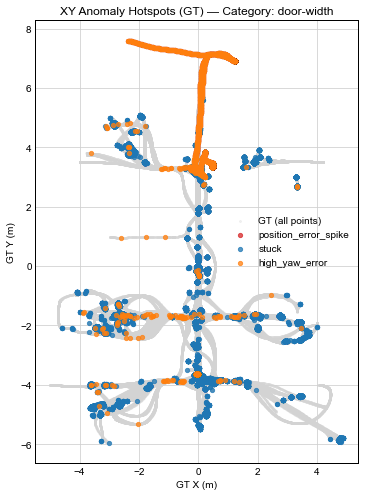

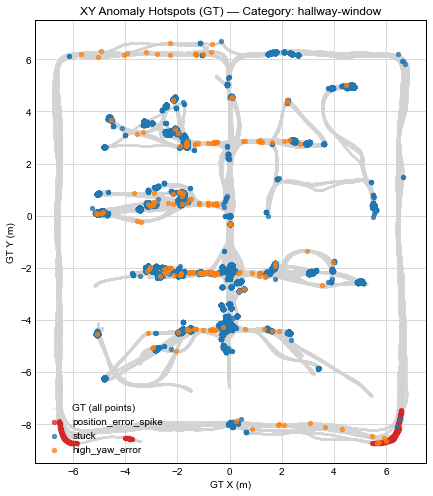

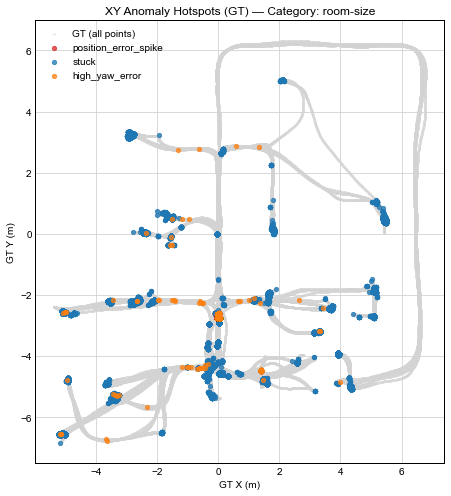

In [13]:
# 9.5 XY anomaly hotspots (GT position) by category - focused on specific anomalies
import re

def _safe_slug(s: str) -> str:
    s = str(s).strip().lower()
    s = re.sub(r'[^a-z0-9]+', '_', s)
    return s.strip('_') or 'category'

def _compute_global_pos_error_threshold(runs, sigma: float = 3.0) -> float:
    vals = []
    for r in runs:
        if r.is_valid and r.time_series_metrics is not None and 'pos_error' in r.time_series_metrics:
            vals.extend(r.time_series_metrics['pos_error'].dropna().values.tolist())
    if not vals:
        return float('inf')
    mu = float(np.mean(vals))
    sd = float(np.std(vals))
    return mu + sigma * sd


all_categories = sorted({r.scenario_category for r in valid_runs})
print('All categories used for XY anomaly plots:', all_categories)

# anomaly -> (color, predicate over run.time_series_metrics)
pos_spike_thr = _compute_global_pos_error_threshold(valid_runs, sigma=3.0)
velocity_thr = 0.01
yaw_thr = 0.5

anomaly_defs = {
    'position_error_spike': ('tab:red', lambda ts: ts['pos_error'] > pos_spike_thr),
    'stuck': ('tab:blue', lambda ts: ts['linear_vel'] < velocity_thr),
    'high_yaw_error': ('tab:orange', lambda ts: ts['yaw_error'] > yaw_thr),
}

for cat in all_categories:
    # Collect GT points for each anomaly type in this category
    points = {k: {'x': [], 'y': []} for k in anomaly_defs.keys()}
    bg_x, bg_y = [], []

    cat_runs = [r for r in valid_runs if r.scenario_category == cat and r.synced_data is not None and r.time_series_metrics is not None]
    for r in cat_runs:
        synced = r.synced_data.reset_index(drop=True)
        ts = r.time_series_metrics.reset_index(drop=True)
        n = min(len(synced), len(ts))
        if n < 3:
            continue
        synced = synced.iloc[:n]
        ts = ts.iloc[:n]

        # background: all GT positions (helps see where points lie)
        bg_x.extend(synced['gt_x'].values.tolist())
        bg_y.extend(synced['gt_y'].values.tolist())

        for name, (_, mask_fn) in anomaly_defs.items():
            # guard missing columns
            try:
                mask = mask_fn(ts).fillna(False).values
            except Exception:
                continue
            if mask.any():
                points[name]['x'].extend(synced.loc[mask, 'gt_x'].values.tolist())
                points[name]['y'].extend(synced.loc[mask, 'gt_y'].values.tolist())

    fig, ax = plt.subplots(figsize=(8, 7))

    if bg_x:
        ax.scatter(bg_x, bg_y, s=4, c='lightgray', alpha=0.25, label='GT (all points)')

    any_anom = False
    for name, (color, _) in anomaly_defs.items():
        x = points[name]['x']
        y = points[name]['y']
        if x:
            any_anom = True
            ax.scatter(x, y, s=18, c=color, alpha=0.75, label=name)

    ax.set_title(f'XY Anomaly Hotspots (GT) — Category: {cat}')
    ax.set_xlabel('GT X (m)')
    ax.set_ylabel('GT Y (m)')
    ax.set_aspect('equal', adjustable='box')
    ax.legend(loc='best')
    plt.tight_layout()

    out = IMAGES_PATH / f"anomaly_xy_{_safe_slug(cat)}.png"
    plt.savefig(out, dpi=150)
    plt.show()

    if not any_anom:
        print(f'Note: no time-localizable anomaly points found for category={cat} under current thresholds.')

## 10. Early Prediction Analysis (expanded: outcome + anomaly prediction)

In [14]:
from typing import Optional, Dict, List, Tuple
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

EARLY_FRACTION = 0.30

def _to_seconds(ts_like: np.ndarray) -> np.ndarray:
    arr = np.asarray(ts_like, dtype=float)
    med = np.nanmedian(arr) if arr.size else np.nan
    if np.isfinite(med) and med > 1e8:
        return arr / 1e9
    return arr

def _path_length_xy(x: np.ndarray, y: np.ndarray) -> float:
    if x is None or y is None or len(x) < 2:
        return 0.0
    return float(np.sum(np.sqrt(np.diff(x) ** 2 + np.diff(y) ** 2)))

def _smoothness_from_angular_vel(t: np.ndarray, w: np.ndarray) -> float:
    if t is None or w is None or len(t) < 3 or len(w) < 3:
        return 0.0
    dt = np.diff(t)
    dt = np.where(dt == 0, 1e-6, dt)
    dw = np.diff(w)
    acc = dw / dt[: len(dw)]
    return float(np.nanmean(np.abs(acc)))

def _amcl_uncertainty_window(amcl_data, t0_s: float, t1_s: float) -> Tuple[float, float]:
    covs = getattr(amcl_data, 'covariances', None)
    ts_attr = getattr(amcl_data, 'timestamps', None)
    if amcl_data is None or covs is None or ts_attr is None or len(ts_attr) == 0:
        return np.nan, np.nan
    amcl_t = _to_seconds(np.asarray(ts_attr, dtype=float))
    if amcl_t.size == 0:
        return np.nan, np.nan
    mask = (amcl_t >= float(t0_s)) & (amcl_t <= float(t1_s))
    idx = np.where(mask)[0]
    if idx.size == 0:
        return np.nan, np.nan
    vals = []
    for i in idx:
        try:
            cov = covs[i]
            vals.append(float(np.sqrt(cov[0, 0] + cov[1, 1])))
        except Exception:
            continue
    if not vals:
        return np.nan, np.nan
    return float(np.mean(vals)), float(np.max(vals))

def compute_early_metrics(run: RunData, fraction: float = 0.3) -> Optional[Dict]:
    if (not run.is_valid) or run.time_series_metrics is None or run.synced_data is None:
        return None
    ts = run.time_series_metrics.reset_index(drop=True).copy()
    synced = run.synced_data.reset_index(drop=True).copy()
    if len(ts) < 5 or len(synced) < 5:
        return None

    t = _to_seconds(ts['timestamp'].values)
    if not np.all(np.isfinite(t)):
        return None
    t0, tN = float(t[0]), float(t[-1])
    if tN <= t0:
        return None
    t_cut = t0 + float(fraction) * (tN - t0)
    m = t <= t_cut
    if int(m.sum()) < 3:
        # fallback: by count if time-based mask yields too few samples
        n_early = max(3, int(len(ts) * fraction))
        m = np.zeros(len(ts), dtype=bool)
        m[:n_early] = True

    early_ts = ts.loc[m].copy()
    early_synced = synced.iloc[: len(early_ts)].copy()

    pos_err = early_ts['pos_error'].astype(float).values
    yaw_err = early_ts['yaw_error'].astype(float).values
    lin_v = early_ts['linear_vel'].astype(float).values
    ang_v = early_ts['angular_vel'].astype(float).values
    t_e = _to_seconds(early_ts['timestamp'].values)

    est_len = _path_length_xy(early_synced['est_x'].values, early_synced['est_y'].values)
    gt_len = _path_length_xy(early_synced['gt_x'].values, early_synced['gt_y'].values)
    peff = (gt_len / est_len) if est_len > 0 else 0.0
    dur = float(t_e[-1] - t_e[0]) if len(t_e) >= 2 else 0.0
    smooth = _smoothness_from_angular_vel(t_e, ang_v)
    amcl_mean, amcl_max = _amcl_uncertainty_window(run.amcl_data, t_e[0], t_e[-1])

    return {
        # identifiers for joining back to RunData
        'scenario': run.scenario_name,
        'run_id': run.run_id,
        'category': run.scenario_category,
        'outcome': run.outcome,
        'early_fraction': float(fraction),
        # early features (requested metric family)
        'early_mean_pos_error': float(np.nanmean(pos_err)),
        'early_rmse_pos': float(np.sqrt(np.nanmean(pos_err ** 2))),
        'early_max_pos_error': float(np.nanmax(pos_err)),
        'early_mean_yaw_error': float(np.nanmean(yaw_err)),
        'early_path_length': float(est_len),
        'early_duration': float(dur),
        'early_path_efficiency': float(peff),
        'early_mean_velocity': float(np.nanmean(lin_v)),
        'early_smoothness': float(smooth),
        'early_amcl_uncertainty': float(amcl_mean) if np.isfinite(amcl_mean) else np.nan,
        'early_max_amcl_uncertainty': float(amcl_max) if np.isfinite(amcl_max) else np.nan,
    }

# Build early feature table
early_rows = []
for run in valid_runs:
    row = compute_early_metrics(run, fraction=EARLY_FRACTION)
    if row is not None:
        early_rows.append(row)

early_df = pd.DataFrame(early_rows)
print(f'Early phase feature table (fraction={EARLY_FRACTION:.2f}): {len(early_df)} runs')
display(early_df.head())

# ---------------------------
# A) Outcome prediction (kept: success vs failure only)
# ---------------------------
metrics_early_cols = [
    'early_mean_pos_error', 'early_rmse_pos', 'early_max_pos_error', 'early_mean_yaw_error',
    'early_path_length', 'early_duration', 'early_path_efficiency', 'early_mean_velocity',
    'early_smoothness', 'early_amcl_uncertainty', 'early_max_amcl_uncertainty'
]

df_sf = early_df[early_df['outcome'].isin(['success', 'failure'])].copy()
if len(df_sf) >= 30 and df_sf['outcome'].nunique() == 2:
    X = df_sf[metrics_early_cols].values
    y = (df_sf['outcome'] == 'failure').astype(int).values
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)),
    ])
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc = cross_val_score(pipe, X, y, scoring='roc_auc', cv=cv)
    ap = cross_val_score(pipe, X, y, scoring='average_precision', cv=cv)
    print('\nOutcome prediction (success vs failure) using early metrics:')
    print(f'  ROC-AUC: {auc.mean():.3f} ± {auc.std():.3f}')
    print(f'  PR-AUC : {ap.mean():.3f} ± {ap.std():.3f}')
else:
    print('\nOutcome prediction: skipped (need enough success/failure samples).')

# ---------------------------
# B) Anomaly prediction (multi-label; one binary model per anomaly label)
# ---------------------------
run_key_to_anoms = {
    (r.scenario_name, r.run_id): (r.anomalies or [])
    for r in valid_runs
}

all_labels = sorted({
    a for r in valid_runs for a in (r.anomalies or [])
    if a and a != 'none'
})
print('\nAnomaly labels found:', all_labels)

# attach per-run anomaly indicators to early_df
for lab in all_labels:
    early_df[f'anom__{lab}'] = early_df.apply(
        lambda row: int(lab in run_key_to_anoms.get((row['scenario'], int(row['run_id'])), [])),
        axis=1,
    )

X_all = early_df[metrics_early_cols].values
pipe_anom = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=4000, class_weight='balanced', random_state=42)),
])

MIN_POS = 12  # robustness: require enough positives to evaluate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

anom_rows = []
coef_rows = []
for lab in all_labels:
    y_lab = early_df[f'anom__{lab}'].astype(int).values
    pos = int(y_lab.sum())
    neg = int(len(y_lab) - pos)
    if pos < MIN_POS or neg < MIN_POS:
        continue

    roc = cross_val_score(pipe_anom, X_all, y_lab, scoring='roc_auc', cv=cv)
    pr = cross_val_score(pipe_anom, X_all, y_lab, scoring='average_precision', cv=cv)
    anom_rows.append({
        'anomaly': lab,
        'positives': pos,
        'negatives': neg,
        'roc_auc_mean': float(roc.mean()),
        'roc_auc_std': float(roc.std()),
        'pr_auc_mean': float(pr.mean()),
        'pr_auc_std': float(pr.std()),
    })

    # fit once for interpretability (standardized coefficients)
    pipe_anom.fit(X_all, y_lab)
    coefs = pipe_anom.named_steps['clf'].coef_.ravel()
    for feat, c in zip(metrics_early_cols, coefs):
        coef_rows.append({'anomaly': lab, 'feature': feat, 'coef': float(c)})

anom_pred_df = pd.DataFrame(anom_rows).sort_values('pr_auc_mean', ascending=False)
coef_long_df = pd.DataFrame(coef_rows)

print('\nEarly anomaly prediction (one model per anomaly; PR-AUC is most informative under imbalance):')
if len(anom_pred_df) == 0:
    print(f'  No anomalies met MIN_POS={MIN_POS} for robust CV evaluation.')
else:
    display(anom_pred_df)

# Coefficient heatmap for top-K anomalies
TOP_K = 6
if len(anom_pred_df) > 0:
    top_labels = anom_pred_df.head(TOP_K)['anomaly'].tolist()
    sub = coef_long_df[coef_long_df['anomaly'].isin(top_labels)].copy()
    # pick features with largest mean |coef| across selected anomalies for a readable heatmap
    feat_rank = (sub.assign(abs_coef=sub['coef'].abs())
                  .groupby('feature')['abs_coef'].mean()
                  .sort_values(ascending=False))
    top_feats = feat_rank.head(10).index.tolist()
    coef_heatmap_df = (sub[sub['feature'].isin(top_feats)]
                       .pivot_table(index='anomaly', columns='feature', values='coef', aggfunc='mean')
                       .reindex(index=top_labels, columns=top_feats))
else:
    coef_heatmap_df = None

Early phase feature table (fraction=0.30): 300 runs


,scenario,run_id,category,outcome,early_fraction,early_mean_pos_error,early_rmse_pos,early_max_pos_error,early_mean_yaw_error,early_path_length,early_duration,early_path_efficiency,early_mean_velocity,early_smoothness,early_amcl_uncertainty,early_max_amcl_uncertainty
0,small-dataset-maps-0-3-door-width-1f1-1,0,door-width,failure,0.3,0.020978,0.023363,0.028556,0.038386,0.046144,3.816,0.011145,0.012638,0.547579,0.141421,0.141421
1,small-dataset-maps-0-3-door-width-1f1-1,1,door-width,failure,0.3,0.022491,0.025164,0.030704,0.038157,0.051074,3.636,0.007535,0.014272,0.602259,0.141421,0.141421
2,small-dataset-maps-0-3-door-width-1f1-1,2,door-width,failure,0.3,0.010299,0.010670,0.012212,0.046345,0.041579,3.636,0.007621,0.011853,0.626251,0.141421,0.141421
3,small-dataset-maps-0-33-door-width-1f1-2,0,door-width,failure,0.3,0.029931,0.033473,0.040893,0.055721,0.062768,3.708,0.003976,0.017524,0.509201,0.141421,0.141421
4,small-dataset-maps-0-33-door-width-1f1-2,1,door-width,failure,0.3,0.024476,0.026004,0.030575,0.049765,0.062351,3.636,0.003709,0.017938,0.577629,0.141421,0.141421



Outcome prediction (success vs failure) using early metrics:
  ROC-AUC: 0.823 ± 0.062
  PR-AUC : 0.864 ± 0.046

Anomaly labels found: ['goal_failure', 'high_yaw_error', 'ml_anomaly', 'path_inefficiency', 'position_error_spike', 'stuck']

Early anomaly prediction (one model per anomaly; PR-AUC is most informative under imbalance):


,anomaly,positives,negatives,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
0,goal_failure,150,150,0.811111,0.054781,0.837562,0.036696
3,stuck,115,185,0.792244,0.053749,0.765642,0.073848
2,position_error_spike,15,285,0.877193,0.065434,0.501666,0.207757
1,ml_anomaly,45,255,0.677560,0.116691,0.431405,0.136907


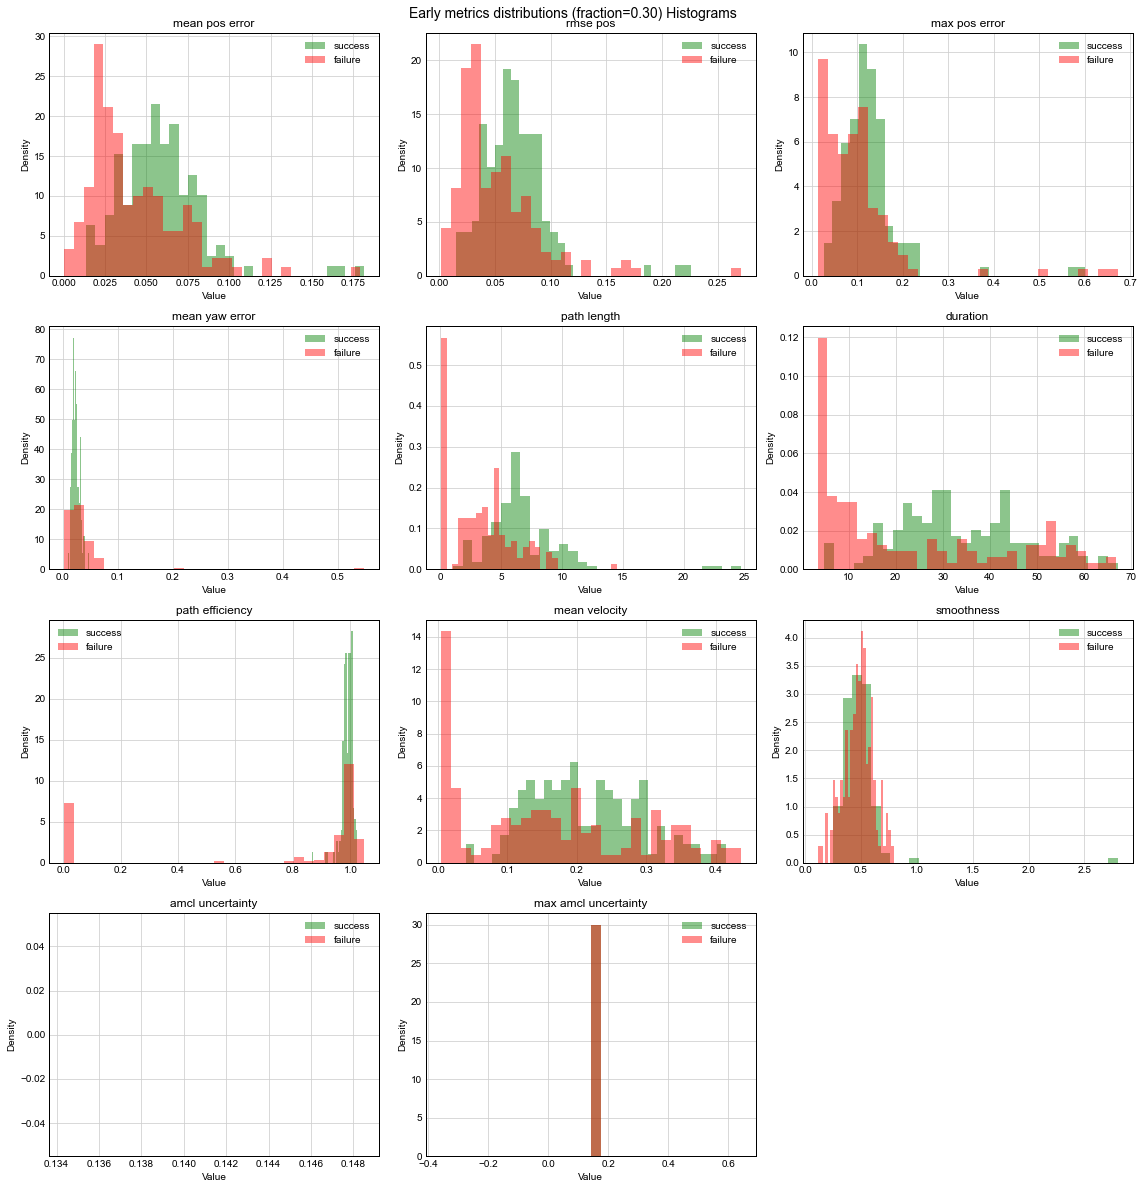

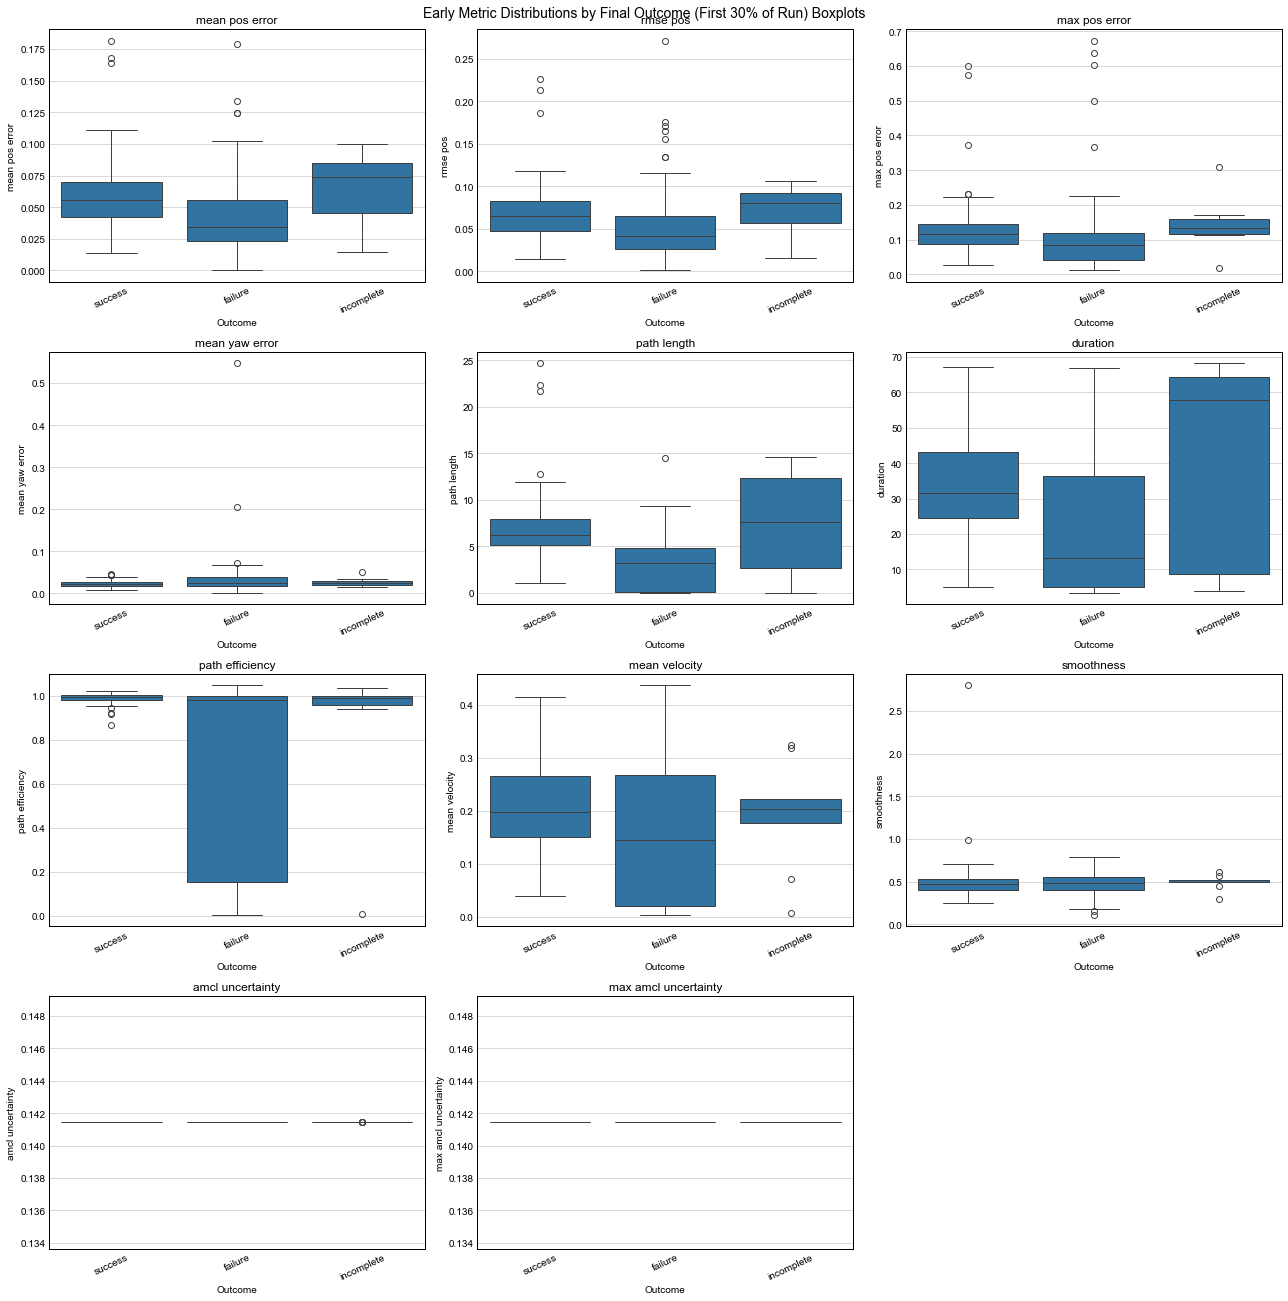

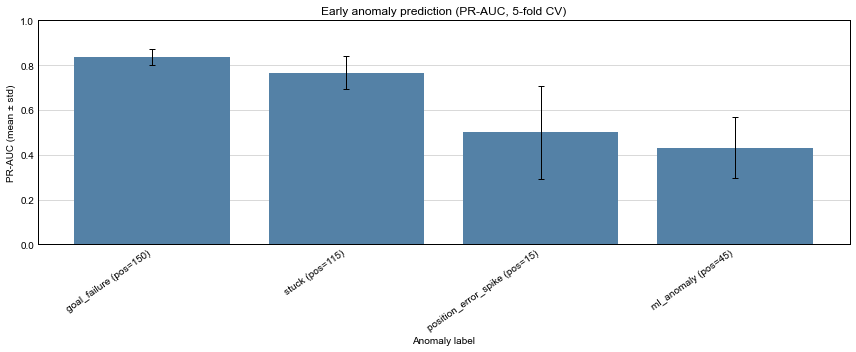

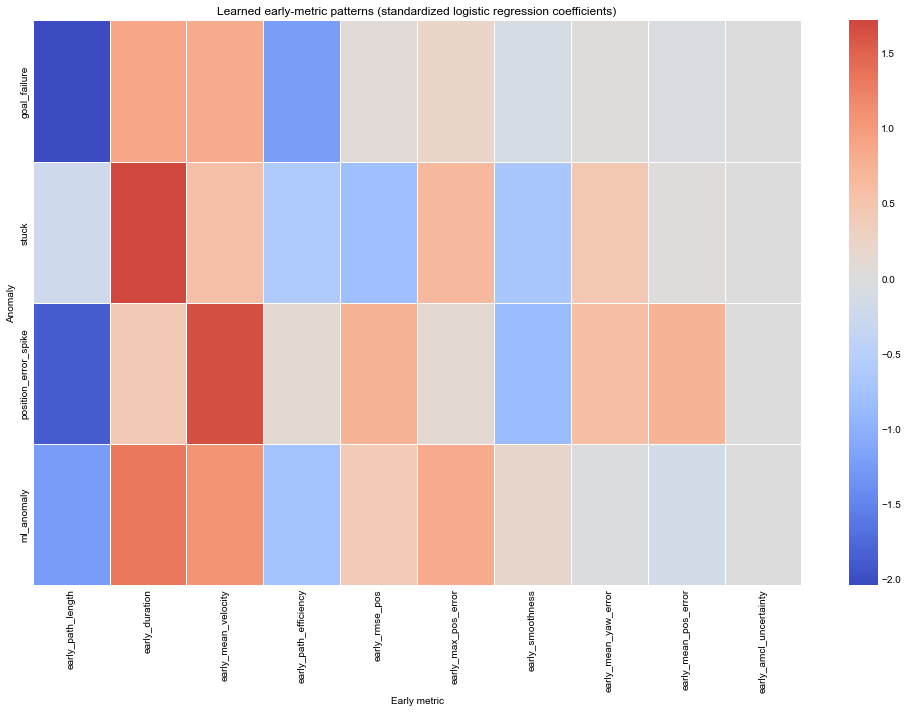

In [15]:
# Visualize early metrics + anomaly predictability/patterns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1a) Histograms like the reference (early metrics by FINAL outcome)
df_sf = early_df[early_df['outcome'].isin(['success', 'failure'])].copy()
metrics_early_cols = [
    'early_mean_pos_error', 'early_rmse_pos', 'early_max_pos_error', 'early_mean_yaw_error',
    'early_path_length', 'early_duration', 'early_path_efficiency', 'early_mean_velocity',
    'early_smoothness', 'early_amcl_uncertainty', 'early_max_amcl_uncertainty'
]

if len(df_sf) > 0:
    cols = 3
    rows = int(np.ceil(len(metrics_early_cols) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4.2 * rows))
    axes = np.array(axes).reshape(rows, cols)
    for ax, col in zip(axes.flat, metrics_early_cols):
        for outcome, color in [('success', 'green'), ('failure', 'red')]:
            v = df_sf[df_sf['outcome'] == outcome][col].dropna()
            if len(v):
                ax.hist(v, bins=30, alpha=0.45, density=True, label=outcome, color=color)
        ax.set_title(col.replace('early_', '').replace('_', ' '))
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')
        ax.legend()
    for k in range(len(metrics_early_cols), rows * cols):
        axes.flat[k].set_visible(False)
    plt.suptitle(f'Early metrics distributions (fraction={EARLY_FRACTION:.2f}) Histograms', fontsize=14)
    plt.tight_layout()
    plt.savefig(IMAGES_PATH / 'Early metrics distributions Histograms.png', dpi=150)
    plt.show()

# 1b) Boxplots of early metrics by FINAL outcome (all outcomes)
df_box = early_df.copy()
if len(df_box) > 0:
    # preferred order; will be filtered to what exists
    preferred = ['success', 'failure', 'incomplete', 'no_navigation', 'no_data', 'unknown']
    present = [o for o in preferred if o in df_box['outcome'].unique().tolist()]
    if not present:
        present = sorted(df_box['outcome'].dropna().unique().tolist())

    cols = 3
    rows = int(np.ceil(len(metrics_early_cols) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(18, 4.6 * rows))
    axes = np.array(axes).reshape(rows, cols)

    for ax, col in zip(axes.flat, metrics_early_cols):
        sns.boxplot(
            data=df_box,
            x='outcome',
            y=col,
            order=present,
            ax=ax,
            showfliers=True,
        )
        ax.set_title(col.replace('early_', '').replace('_', ' '))
        ax.set_xlabel('Outcome')
        ax.set_ylabel(col.replace('early_', '').replace('_', ' '))
        ax.tick_params(axis='x', rotation=25)

    for k in range(len(metrics_early_cols), rows * cols):
        axes.flat[k].set_visible(False)

    plt.suptitle(
        f'Early Metric Distributions by Final Outcome (First {int(EARLY_FRACTION*100)}% of Run) Boxplots',
        fontsize=14,
    )
    plt.tight_layout()
    plt.savefig(IMAGES_PATH / 'early_metric_boxplots_by_outcome.png', dpi=150)
    plt.show()

# 2) Anomaly predictability (PR-AUC) — robust indicator under imbalance
if 'anom_pred_df' in globals() and anom_pred_df is not None and len(anom_pred_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    plot_df = anom_pred_df.copy()
    plot_df['label'] = plot_df.apply(lambda r: f"{r['anomaly']} (pos={int(r['positives'])})", axis=1)
    sns.barplot(data=plot_df, x='label', y='pr_auc_mean', ax=ax, color='steelblue')
    ax.errorbar(
        x=np.arange(len(plot_df)),
        y=plot_df['pr_auc_mean'].values,
        yerr=plot_df['pr_auc_std'].values,
        fmt='none', ecolor='black', elinewidth=1, capsize=3,
    )
    ax.set_title('Early anomaly prediction (PR-AUC, 5-fold CV)')
    ax.set_xlabel('Anomaly label')
    ax.set_ylabel('PR-AUC (mean ± std)')
    ax.set_ylim(0, 1.0)
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.savefig(IMAGES_PATH / 'early_anomaly_pr_auc.png', dpi=150)
    plt.show()

    # 3) Coefficient heatmap (patterns): which early metrics push anomaly probability up/down
    if 'coef_heatmap_df' in globals() and coef_heatmap_df is not None:
        plt.figure(figsize=(14,10))
        sns.heatmap(coef_heatmap_df, cmap='coolwarm', center=0, linewidths=0.5)
        plt.title('Learned early-metric patterns (standardized logistic regression coefficients)')
        plt.xlabel('Early metric')
        plt.ylabel('Anomaly')
        plt.tight_layout()
        plt.savefig(IMAGES_PATH / 'early_anomaly_coef_heatmap.png', dpi=150)
        plt.show()
else:
    print('No anomaly prediction results to plot (insufficient positives per label).')

## 12. Save Results

In [16]:
# Save summary to CSV
summary_df.to_csv('analysis_summary.csv', index=False)
print('Summary saved to analysis_summary.csv')

# List generated figures
print('\nGenerated figures in images/:')
for f in IMAGES_PATH.glob('*.png'):
    print(f'  - {f.name}')

Summary saved to analysis_summary.csv

Generated figures in images/:
  - anomaly_xy_by_label_room_size.png
  - metric_distributions.png
  - anomaly_xy_by_label_hallway_window.png
  - anomaly_xy_room_size.png
  - early_anomaly_pr_auc.png
  - sample_trajectories.png
  - anomaly_by_category.png
  - anomaly_xy_by_label_door_width.png
  - early_anomaly_coef_heatmap.png
  - anomaly_xy_hallway_window.png
  - Early metrics distributions Histograms.png
  - anomaly_xy_door_width.png
  - early_metric_boxplots_by_outcome.png
